**TRAIN ON COLLAB**

In [1]:
!git clone https://github.com/DionHoang/DEEPLEARNING.git

Cloning into 'DEEPLEARNING'...
remote: Enumerating objects: 309, done.
remote: Counting objects: 100% (182/182), done.
remote: Compressing objects: 100% (110/110), done.
remote: Total 309 (delta 105), reused 131 (delta 70), pack-reused 127 (from 1)
Receiving objects: 100% (309/309), 1.35 MiB | 32.05 MiB/s, done.
Resolving deltas: 100% (169/169), done.


In [2]:
%cd DEEPLEARNING

/content/DEEPLEARNING


**NOTE**:
- Để không bị lộ API_KEY, HF_TOKEN,... thì ta lưu các keys này ở trong phần khoá bí mật của Colab.

- Do cần push kết quả sau khi train nên sẽ có thêm GITHUB_TOKEN.

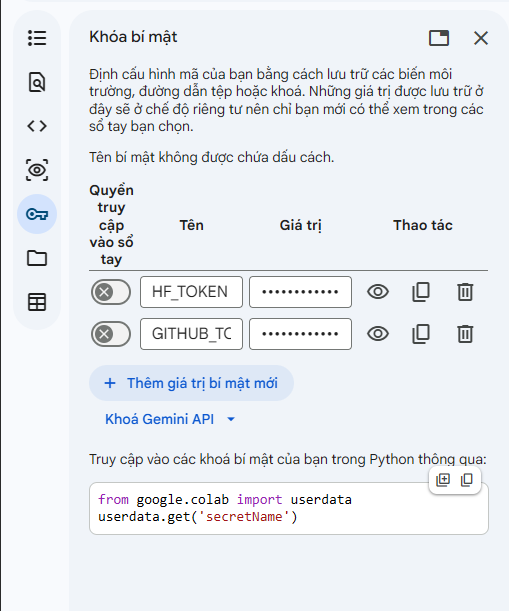

In [3]:
!pip install -q transformers pyvi seqeval peft streamlit gradio
!pip install -q --upgrade torchao peft

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 104.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 126.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 120.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 109.5 MB/s eta 0:00:00


In [4]:
from google.colab import userdata

hf_token = userdata.get("HF_TOKEN")
github_token = userdata.get("GITHUB_TOKEN")
with open(".env", "w") as f:
    f.write(f"HF_TOKEN={hf_token}\n")
    f.write(f"GITHUB_TOKEN={github_token}\n")

In [5]:
!git config --global user.name "ducbao_210"
!git config --global user.email "nguyenducbao2005@gmail.com"

In [6]:
!git remote -v

origin	https://github.com/DionHoang/DEEPLEARNING.git (fetch)
origin	https://github.com/DionHoang/DEEPLEARNING.git (push)


# **CRF**

In [7]:
!python main.py --mode train --model all --use_crf --epochs 10
!python main.py --mode evaluate --model all --use_crf

Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so
2026-06-10 00:53:10.927357: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-10 00:53:10.992046: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow w

In [8]:
!python main.py --mode distill --model all --use_crf --epochs 10
!python main.py --mode evaluate --model lstm --use_crf --checkpoint results/lstm_distilled_crf/checkpoints/best_model.pt
!python main.py --mode evaluate --model bilstm --use_crf --checkpoint results/bilstm_distilled_crf/checkpoints/best_model.pt
!python main.py --mode evaluate --model transformer --use_crf --checkpoint results/transformer_distilled_crf/checkpoints/best_model.pt

Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so
2026-06-10 03:59:11.420060: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-10 03:59:11.490372: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow w

In [9]:
!python main.py --mode quantize --model all --use_crf
!python main.py --mode evaluate --model lstm --use_crf --checkpoint results/lstm_crf/checkpoints/lstm_quantized_ptq.pt
!python main.py --mode evaluate --model bilstm --use_crf --checkpoint results/bilstm_crf/checkpoints/bilstm_quantized_ptq.pt
!python main.py --mode evaluate --model transformer --use_crf --checkpoint results/transformer_crf/checkpoints/transformer_quantized_ptq.pt

Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so
2026-06-10 04:49:56.955785: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-10 04:49:57.026685: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow w

In [10]:
!python main.py --mode train_qat --model all --use_crf --epochs 10

Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so
2026-06-10 04:52:27.227993: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-10 04:52:27.296896: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow w

In [11]:
!python main.py --mode evaluate --model lstm --use_crf --checkpoint results/lstm_qat_crf/checkpoints/best_model.pt
!python main.py --mode evaluate --model bilstm --use_crf --checkpoint results/bilstm_qat_crf/checkpoints/best_model.pt
!python main.py --mode evaluate --model transformer --use_crf --checkpoint results/transformer_qat_crf/checkpoints/best_model.pt

Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so
2026-06-10 07:44:33.223831: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-10 07:44:33.295603: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow w

# **Non-CRF**

In [ ]:
!python main.py --mode train --model all --epochs 10
!python main.py --mode evaluate --model all

Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so
2026-06-10 01:13:38.443247: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-10 01:13:40 - main_orchestrator - WARNING - HF_TOKEN not found in environment variables.
2026-06-10 01:13:40 - main_orchestrator - INFO - Chế độ huấn luyện/đánh giá toàn bộ các mô hình tuần tự.
2026-06-10 01:13:40 - main_orchestrator - INFO - Using compute targe

In [ ]:
!python main.py --mode distill --model all --epochs 10
!python main.py --mode evaluate --model lstm --checkpoint results/lstm_distilled/checkpoints/best_model.pt
!python main.py --mode evaluate --model bilstm --checkpoint results/bilstm_distilled/checkpoints/best_model.pt
!python main.py --mode evaluate --model transformer --checkpoint results/transformer_distilled/checkpoints/best_model.pt

Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so
2026-06-10 03:24:11.042760: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-10 03:24:13 - main_orchestrator - WARNING - HF_TOKEN not found in environment variables.
2026-06-10 03:24:13 - main_orchestrator - INFO - Chế độ huấn luyện/đánh giá toàn bộ các mô hình tuần tự.
2026-06-10 03:24:13 - main_orchestrator - INFO - Using compute targe

In [ ]:
!python main.py --mode quantize --model all
!python main.py --mode evaluate --model lstm --checkpoint results/lstm/checkpoints/lstm_quantized_ptq.pt
!python main.py --mode evaluate --model bilstm --checkpoint results/bilstm/checkpoints/bilstm_quantized_ptq.pt
!python main.py --mode evaluate --model transformer --checkpoint results/transformer/checkpoints/transformer_quantized_ptq.pt

Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so
2026-06-10 04:15:33.560363: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-10 04:15:36 - main_orchestrator - WARNING - HF_TOKEN not found in environment variables.
2026-06-10 04:15:36 - main_orchestrator - INFO - Chế độ huấn luyện/đánh giá toàn bộ các mô hình tuần tự.
2026-06-10 04:15:36 - main_orchestrator - INFO - Using compute targe

In [ ]:
!python main.py --mode train_qat --model all --epochs 10
!python main.py --mode evaluate --model lstm --checkpoint results/lstm_qat/checkpoints/best_model.pt
!python main.py --mode evaluate --model bilstm --checkpoint results/bilstm_qat/checkpoints/best_model.pt
!python main.py --mode evaluate --model transformer --checkpoint results/transformer_qat/checkpoints/best_model.pt

Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so
2026-06-10 04:20:37.675669: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-10 04:20:40 - main_orchestrator - WARNING - HF_TOKEN not found in environment variables.
2026-06-10 04:20:40 - main_orchestrator - INFO - Chế độ huấn luyện/đánh giá toàn bộ các mô hình tuần tự.
2026-06-10 04:20:40 - main_orchestrator - INFO - Using compute targe